In [7]:
# -------------------- imports_section --------------------
# (This is the "imports.py" logical section)

import argparse
import os
import warnings
from typing import Dict, Tuple

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    auc,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    precision_recall_curve,
    recall_score,
    roc_auc_score,
    roc_curve
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Optional imports
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

try:
    from imblearn.over_sampling import SMOTE
    IMBLEARN_AVAILABLE = True
except Exception:
    IMBLEARN_AVAILABLE = False

warnings.filterwarnings('ignore')


In [8]:
# -------------------- load_data_section --------------------
# (Fixed version for Google Colab upload)

import io
import os
import numpy as np
import pandas as pd
from typing import Tuple
from sklearn.model_selection import train_test_split

# Optional imports for SMOTE
try:
    from imblearn.over_sampling import SMOTE
    IMBLEARN_AVAILABLE = True
except:
    IMBLEARN_AVAILABLE = False


def load_and_preprocess(
    data_path,
    target_col: str = "default.payment.next.month",
    drop_cols: list = None,
    test_size: float = 0.2,
    random_state: int = 42,
    use_smote: bool = False
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, dict]:
    """
    Load CSV (from file path or uploaded file), basic preprocessing and train/test split.

    Returns: X_train, X_test, y_train, y_test, metadata
    """
    # --- Load data (from file path, bytes, or file-like object) ---
    if isinstance(data_path, bytes):
        # data_path is raw bytes (e.g., from Colab upload)
        df = pd.read_csv(io.BytesIO(data_path))
    elif hasattr(data_path, "read"):
        # file-like object
        df = pd.read_csv(data_path)
    elif isinstance(data_path, str) and os.path.exists(data_path):
        # local file path
        df = pd.read_csv(data_path)
    else:
        raise FileNotFoundError(
            f"Data file not found or invalid: {data_path}. "
            "Pass either a valid file path, bytes, or uploaded file object."
        )

    # --- Check for target column ---
    if target_col not in df.columns:
        raise ValueError(
            f"Target column '{target_col}' not found. "
            f"Available columns: {df.columns.tolist()}"
        )

    # --- Drop ID or other unwanted columns ---
    if drop_cols is None:
        drop_cols = ['ID'] if 'ID' in df.columns else []
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    # --- Handle missing values ---
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    for c in num_cols:
        df[c] = df[c].fillna(df[c].median())

    # --- Encode categorical columns ---
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    if len(cat_cols) > 0:
        df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

    # --- Split features and target ---
    X = df.drop(columns=[target_col]).values
    y = df[target_col].values

    metadata = {
        'feature_names': df.drop(columns=[target_col]).columns.tolist(),
        'class_counts': dict(pd.Series(y).value_counts())
    }

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )

    # --- Optional SMOTE resampling ---
    if use_smote:
        if not IMBLEARN_AVAILABLE:
            raise RuntimeError("imblearn not installed. Install imbalanced-learn to use SMOTE.")
        sm = SMOTE(random_state=random_state)
        X_train, y_train = sm.fit_resample(X_train, y_train)

    return X_train, X_test, y_train, y_test, metadata


In [9]:
from google.colab import files

# Upload CSV
uploaded = files.upload()

# Get the uploaded file’s content (raw bytes)
file_name = list(uploaded.keys())[0]
file_content = uploaded[file_name]

# Load dataset into the preprocessing function
X_train, X_test, y_train, y_test, metadata = load_and_preprocess(file_content)


Saving UCI_Credit_Card.csv to UCI_Credit_Card (1).csv



Training LogisticRegression ...

LogisticRegression metrics:
 Accuracy=0.8028 | Precision=0.6667 | Recall=0.2170 | F1=0.3275 | ROC-AUC=0.6810
 Error=0.1972 | MSE=0.1972 | MAE=0.1972 | RMSE=0.4440


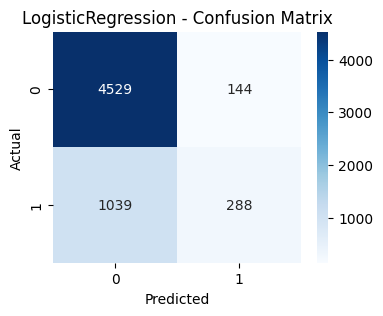


Training SVM ...

SVM metrics:
 Accuracy=0.7788 | Precision=0.0000 | Recall=0.0000 | F1=0.0000 | ROC-AUC=0.5489
 Error=0.2212 | MSE=0.2212 | MAE=0.2212 | RMSE=0.4703


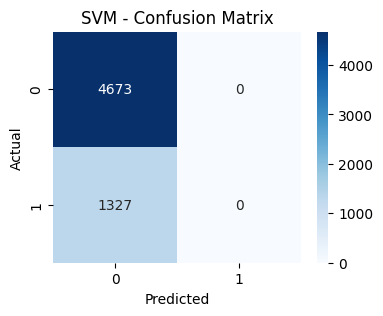


Training RandomForest ...

RandomForest metrics:
 Accuracy=0.8120 | Precision=0.6325 | Recall=0.3580 | F1=0.4572 | ROC-AUC=0.7506
 Error=0.1880 | MSE=0.1880 | MAE=0.1880 | RMSE=0.4336


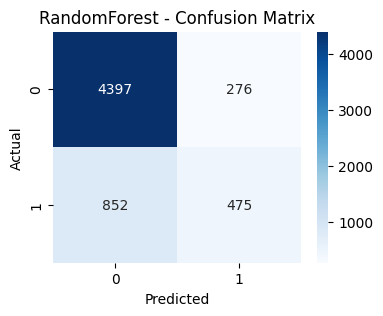

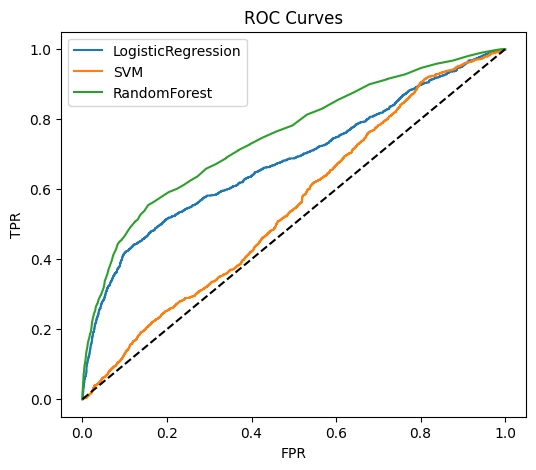

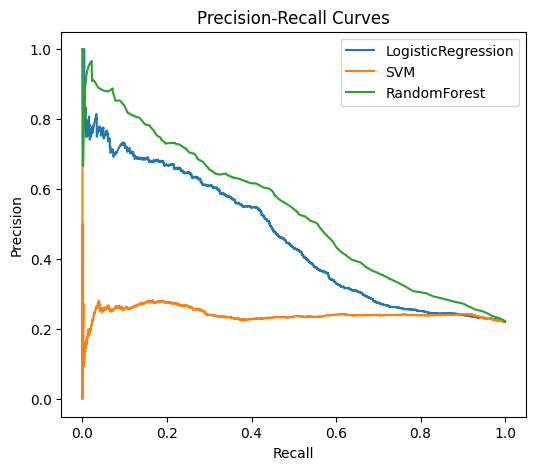


✅ Best model by accuracy: RandomForest (0.8120)
Saved best model as models/RandomForest_final.pkl

Summary:
LogisticRegression: Acc=0.8028, Prec=0.6667, Rec=0.2170, F1=0.3275, ROC-AUC=0.6810
SVM: Acc=0.7788, Prec=0.0000, Rec=0.0000, F1=0.0000, ROC-AUC=0.5489
RandomForest: Acc=0.8120, Prec=0.6325, Rec=0.3580, F1=0.4572, ROC-AUC=0.7506

✅ Best model overall: RandomForest (Accuracy=0.8120)


In [10]:
# -------------------- Build Models --------------------
def build_models():
    return {
        "LogisticRegression": LogisticRegression(max_iter=500, solver="lbfgs"),
        "SVM": SVC(probability=True, kernel="rbf"),
        "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42)
    }

# -------------------- Evaluate Model --------------------
def evaluate_model(name, model, X_test, y_test, y_pred, y_proba):
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    err = 1 - acc
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{name} metrics:")
    print(f" Accuracy={acc:.4f} | Precision={prec:.4f} | Recall={rec:.4f} | "
          f"F1={f1:.4f} | ROC-AUC={roc_auc:.4f}")
    print(f" Error={err:.4f} | MSE={mse:.4f} | MAE={mae:.4f} | RMSE={rmse:.4f}")

    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.show()

    return {
        "model": name, "accuracy": acc, "precision": prec, "recall": rec, "f1_score": f1,
        "roc_auc": roc_auc, "error_rate": err, "mse": mse, "mae": mae, "rmse": rmse,
        "confusion_matrix": cm
    }

# -------------------- Comparative Curves --------------------
def plot_roc_pr_curves(results, y_test):
    plt.figure(figsize=(6,5))
    for r in results:
        fpr, tpr, _ = roc_curve(y_test, r["y_proba"])
        plt.plot(fpr, tpr, label=r["name"])
    plt.plot([0,1], [0,1], 'k--')
    plt.title("ROC Curves"); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend(); plt.show()

    plt.figure(figsize=(6,5))
    for r in results:
        prec, rec, _ = precision_recall_curve(y_test, r["y_proba"])
        plt.plot(rec, prec, label=r["name"])
    plt.title("Precision-Recall Curves"); plt.xlabel("Recall"); plt.ylabel("Precision"); plt.legend(); plt.show()

# -------------------- Train, Evaluate, Select --------------------
def train_evaluate_and_select(models, X_train, X_test, y_train, y_test):
    results, metrics_all = [], []
    os.makedirs("models", exist_ok=True)

    for name, model in models.items():
        print(f"\n{'='*25}\nTraining {name} ...")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None
        metrics = evaluate_model(name, model, X_test, y_test, y_pred, y_proba)
        metrics_all.append(metrics)
        results.append({"name": name, "y_proba": y_proba})
        joblib.dump(model, f"models/{name}_temp.pkl")

    plot_roc_pr_curves(results, y_test)

    best = max(metrics_all, key=lambda m: m["accuracy"])
    print(f"\n✅ Best model by accuracy: {best['model']} ({best['accuracy']:.4f})")

    best_model = joblib.load(f"models/{best['model']}_temp.pkl")
    X_full = np.vstack([X_train, X_test]); y_full = np.concatenate([y_train, y_test])
    best_model.fit(X_full, y_full)
    joblib.dump(best_model, f"models/{best['model']}_final.pkl")
    print(f"Saved best model as models/{best['model']}_final.pkl")

    return metrics_all, best

# -------------------- RUN --------------------
X_train, X_test, y_train, y_test, feature_names = load_and_preprocess(uploaded[file_name])
models = build_models()
metrics_all, best = train_evaluate_and_select(models, X_train, X_test, y_train, y_test)

print("\nSummary:")
for m in metrics_all:
    print(f"{m['model']}: Acc={m['accuracy']:.4f}, Prec={m['precision']:.4f}, Rec={m['recall']:.4f}, "
          f"F1={m['f1_score']:.4f}, ROC-AUC={m['roc_auc']:.4f}")
print(f"\n✅ Best model overall: {best['model']} (Accuracy={best['accuracy']:.4f})")

📂 Please upload your dataset (e.g., UCI_Credit_Card.csv)


Saving UCI_Credit_Card.csv to UCI_Credit_Card (2).csv

Training LogisticRegression ...

LogisticRegression metrics:
 Accuracy=0.8028 | Precision=0.6667 | Recall=0.2170 | F1=0.3275 | ROC-AUC=0.6810
 Error=0.1972 | MSE=0.1972 | MAE=0.1972 | RMSE=0.4440


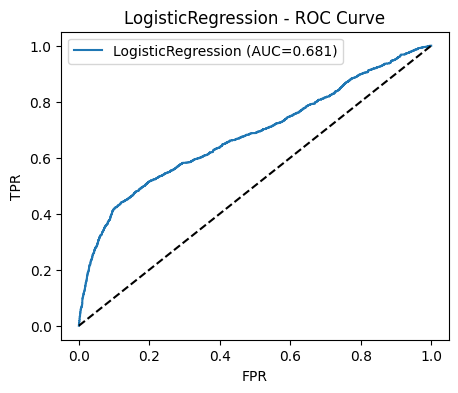

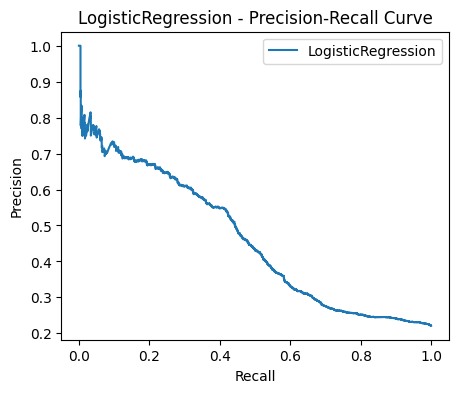

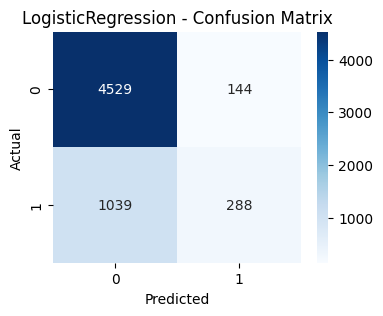


Training RandomForest ...

RandomForest metrics:
 Accuracy=0.8120 | Precision=0.6325 | Recall=0.3580 | F1=0.4572 | ROC-AUC=0.7506
 Error=0.1880 | MSE=0.1880 | MAE=0.1880 | RMSE=0.4336


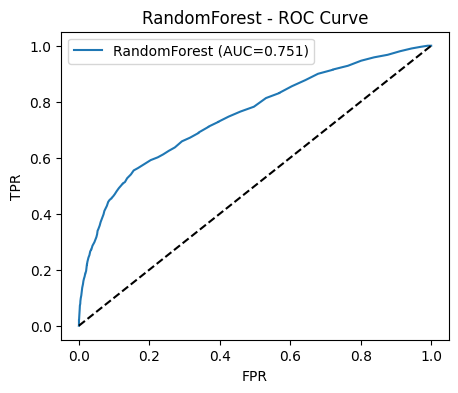

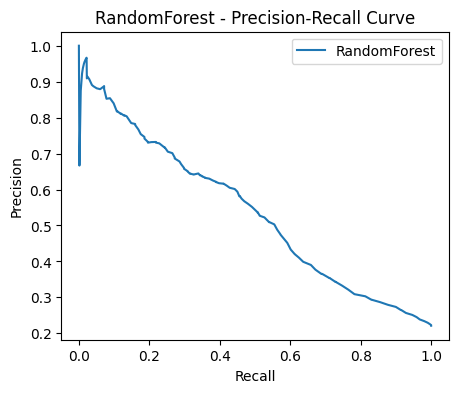

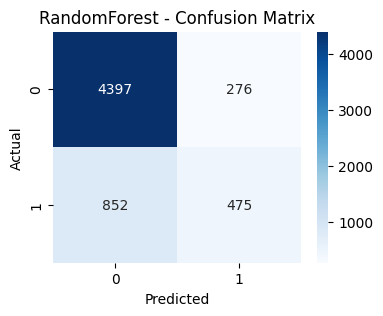


Training XGBoost ...

XGBoost metrics:
 Accuracy=0.8172 | Precision=0.6558 | Recall=0.3647 | F1=0.4688 | ROC-AUC=0.7729
 Error=0.1828 | MSE=0.1828 | MAE=0.1828 | RMSE=0.4276


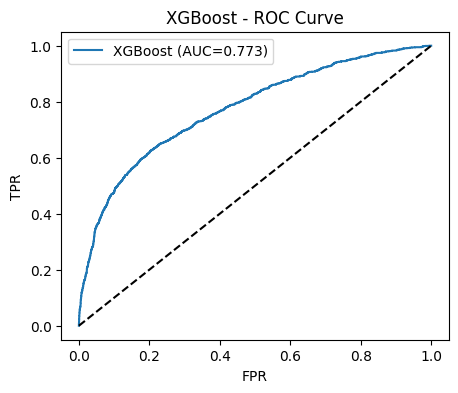

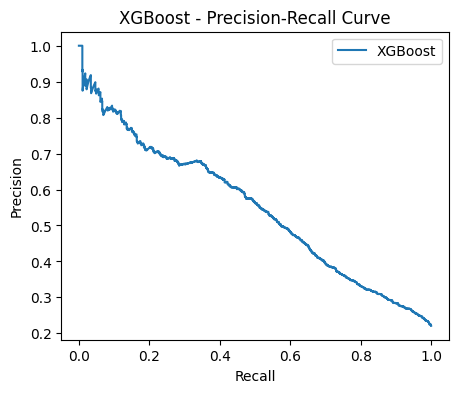

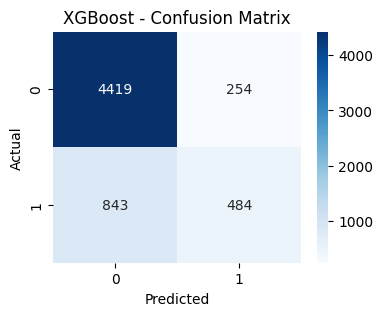


✅ Best model by accuracy: XGBoost (0.8172)
Saved best model as models/XGBoost_final.pkl

📊 Summary:
LogisticRegression: Acc=0.8028, Prec=0.6667, Rec=0.2170, F1=0.3275, ROC-AUC=0.6810
RandomForest: Acc=0.8120, Prec=0.6325, Rec=0.3580, F1=0.4572, ROC-AUC=0.7506
XGBoost: Acc=0.8172, Prec=0.6558, Rec=0.3647, F1=0.4688, ROC-AUC=0.7729

🏆 Best model overall: XGBoost (Accuracy=0.8172)


In [11]:
# ================================================================
# ✅ CREDIT CARD FRAUD DETECTION - FULL COLAB UPLOAD VERSION (XGBoost)
# ================================================================

# -------------------- Imports --------------------
import os, io, joblib, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score, accuracy_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    mean_squared_error, mean_absolute_error
)
from xgboost import XGBClassifier

# -------------------- Upload & Load --------------------
print("📂 Please upload your dataset (e.g., UCI_Credit_Card.csv)")
uploaded = files.upload()
file_name = next(iter(uploaded))  # first uploaded file name

def load_and_preprocess(uploaded_file, target_col="default.payment.next.month",
                        test_size=0.2, random_state=42):
    """Load from uploaded file, preprocess, split."""
    df = pd.read_csv(io.BytesIO(uploaded_file))

    if "ID" in df.columns:
        df = df.drop(columns=["ID"])

    # Fill NaNs
    for c in df.select_dtypes(include=[np.number]).columns:
        df[c] = df[c].fillna(df[c].median())

    # One-hot encode if needed
    cat_cols = df.select_dtypes(include=["object", "category"]).columns
    if len(cat_cols) > 0:
        df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

    X = df.drop(columns=[target_col]).values
    y = df[target_col].values
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state)
    return X_train, X_test, y_train, y_test, df.columns[:-1]

# -------------------- Build Models --------------------
def build_models():
    return {
        "LogisticRegression": LogisticRegression(max_iter=500, solver="lbfgs"),
        "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
        "XGBoost": XGBClassifier(
            n_estimators=200, learning_rate=0.1, max_depth=5,
            subsample=0.8, colsample_bytree=0.8, use_label_encoder=False,
            eval_metric="logloss", random_state=42
        )
    }

# -------------------- Evaluate Model --------------------
def evaluate_model(name, model, X_test, y_test, y_pred, y_proba):
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    err = 1 - acc
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{name} metrics:")
    print(f" Accuracy={acc:.4f} | Precision={prec:.4f} | Recall={rec:.4f} | "
          f"F1={f1:.4f} | ROC-AUC={roc_auc:.4f}")
    print(f" Error={err:.4f} | MSE={mse:.4f} | MAE={mae:.4f} | RMSE={rmse:.4f}")

    # --- ROC Curve ---
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")
    plt.plot([0,1], [0,1], 'k--')
    plt.title(f"{name} - ROC Curve"); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend(); plt.show()

    # --- Precision-Recall Curve ---
    prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba)
    plt.figure(figsize=(5,4))
    plt.plot(rec_curve, prec_curve, label=f"{name}")
    plt.title(f"{name} - Precision-Recall Curve"); plt.xlabel("Recall"); plt.ylabel("Precision"); plt.legend(); plt.show()

    # --- Confusion Matrix Heatmap ---
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.show()

    return {
        "model": name, "accuracy": acc, "precision": prec, "recall": rec, "f1_score": f1,
        "roc_auc": roc_auc, "error_rate": err, "mse": mse, "mae": mae, "rmse": rmse,
        "confusion_matrix": cm
    }

# -------------------- Train, Evaluate, Select --------------------
def train_evaluate_and_select(models, X_train, X_test, y_train, y_test):
    results, metrics_all = [], []
    os.makedirs("models", exist_ok=True)

    for name, model in models.items():
        print(f"\n{'='*25}\nTraining {name} ...")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None
        metrics = evaluate_model(name, model, X_test, y_test, y_pred, y_proba)
        metrics_all.append(metrics)
        results.append({"name": name, "y_proba": y_proba})
        joblib.dump(model, f"models/{name}_temp.pkl")

    best = max(metrics_all, key=lambda m: m["accuracy"])
    print(f"\n✅ Best model by accuracy: {best['model']} ({best['accuracy']:.4f})")

    best_model = joblib.load(f"models/{best['model']}_temp.pkl")
    X_full = np.vstack([X_train, X_test]); y_full = np.concatenate([y_train, y_test])
    best_model.fit(X_full, y_full)
    joblib.dump(best_model, f"models/{best['model']}_final.pkl")
    print(f"Saved best model as models/{best['model']}_final.pkl")

    return metrics_all, best

# -------------------- RUN --------------------
X_train, X_test, y_train, y_test, feature_names = load_and_preprocess(uploaded[file_name])
models = build_models()
metrics_all, best = train_evaluate_and_select(models, X_train, X_test, y_train, y_test)

print("\n📊 Summary:")
for m in metrics_all:
    print(f"{m['model']}: Acc={m['accuracy']:.4f}, Prec={m['precision']:.4f}, Rec={m['recall']:.4f}, "
          f"F1={m['f1_score']:.4f}, ROC-AUC={m['roc_auc']:.4f}")
print(f"\n🏆 Best model overall: {best['model']} (Accuracy={best['accuracy']:.4f})")


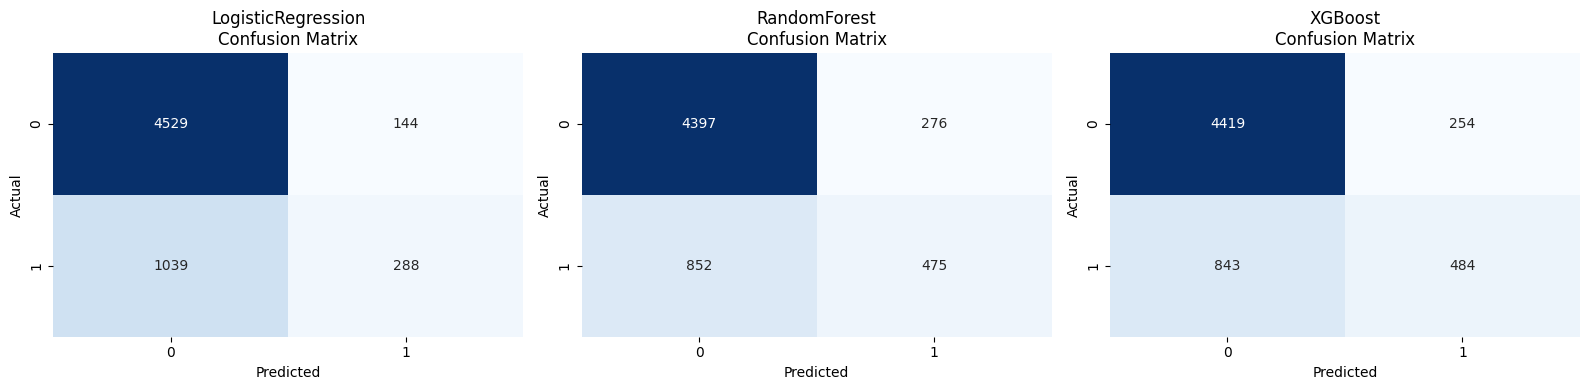

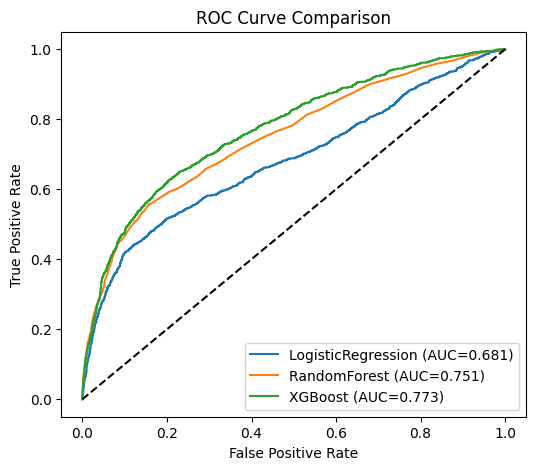

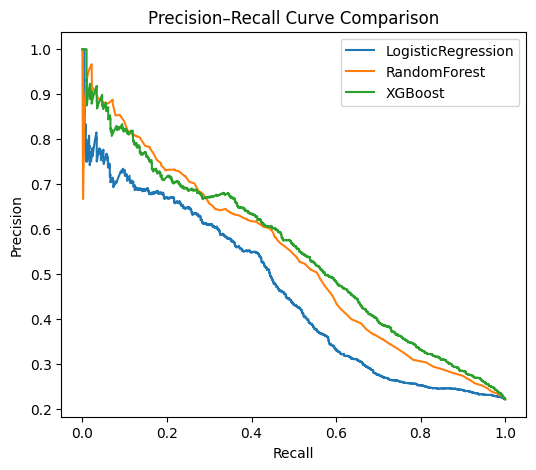

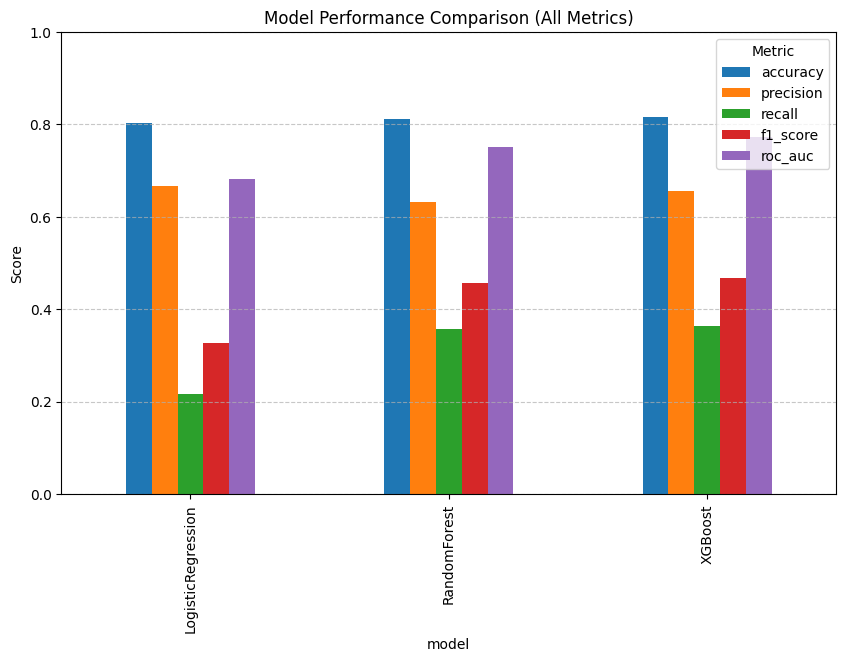

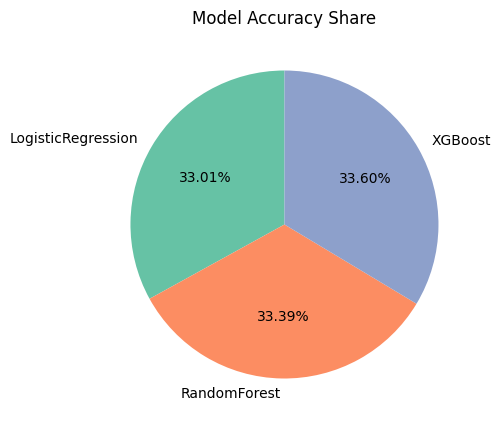

📊 Summary Table of Model Metrics:


,accuracy,precision,recall,f1_score,roc_auc
model,,,,,
LogisticRegression,0.8028,0.6667,0.2170,0.3275,0.6810
RandomForest,0.8120,0.6325,0.3580,0.4572,0.7506
XGBoost,0.8172,0.6558,0.3647,0.4688,0.7729


🏆 Best Model Overall: XGBoost (Accuracy = 0.8172)


In [12]:
# ================================================================
# ✅ OVERALL MODEL COMPARISON DASHBOARD
# ================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import roc_curve, precision_recall_curve
import joblib, numpy as np

# Create a DataFrame of metrics
metric_names = ["accuracy", "precision", "recall", "f1_score", "roc_auc"]
metric_df = pd.DataFrame([{k: m[k] for k in metric_names} | {"model": m["model"]} for m in metrics_all])
metric_df.set_index("model", inplace=True)

# -------------------- 1️⃣ Confusion Matrix Heatmaps --------------------
plt.figure(figsize=(16, 4))
for i, m in enumerate(metrics_all, 1):
    plt.subplot(1, len(metrics_all), i)
    sns.heatmap(m["confusion_matrix"], annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"{m['model']}\nConfusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# -------------------- 2️⃣ Combined ROC Curves --------------------
plt.figure(figsize=(6,5))
for m in metrics_all:
    model = joblib.load(f"models/{m['model']}_temp.pkl")
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:,1]
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X_test)
        y_proba = (scores - scores.min()) / (scores.max() - scores.min())
    else:
        continue
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{m['model']} (AUC={m['roc_auc']:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# -------------------- 3️⃣ Combined Precision-Recall Curves --------------------
plt.figure(figsize=(6,5))
for m in metrics_all:
    model = joblib.load(f"models/{m['model']}_temp.pkl")
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:,1]
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X_test)
        y_proba = (scores - scores.min()) / (scores.max() - scores.min())
    else:
        continue
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    plt.plot(rec, prec, label=f"{m['model']}")
plt.title("Precision–Recall Curve Comparison")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

# -------------------- 4️⃣ Bar Chart of Metrics --------------------
metric_df.plot(kind='bar', figsize=(10,6))
plt.title("Model Performance Comparison (All Metrics)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(title="Metric")
plt.show()

# -------------------- 5️⃣ Pie Chart of Accuracy Contribution --------------------
plt.figure(figsize=(5,5))
plt.pie(metric_df["accuracy"], labels=metric_df.index, autopct='%1.2f%%', startangle=90, colors=sns.color_palette("Set2"))
plt.title("Model Accuracy Share")
plt.show()

# -------------------- 6️⃣ Summary Table --------------------
from IPython.display import display
print("📊 Summary Table of Model Metrics:")
display(metric_df.round(4))

# -------------------- 7️⃣ Highlight Best Model --------------------
best_model = metric_df["accuracy"].idxmax()
print(f"🏆 Best Model Overall: {best_model} (Accuracy = {metric_df.loc[best_model, 'accuracy']:.4f})")


🚀 Training Ensemble (Logistic + RF + XGBoost)...

📊 Ensemble Model Metrics:
 Accuracy=0.8037 | Precision=0.6616 | Recall=0.2298 | F1=0.3412 | ROC-AUC=0.6826
 Error=0.1963 | MSE=0.1963 | MAE=0.1963 | RMSE=0.4431


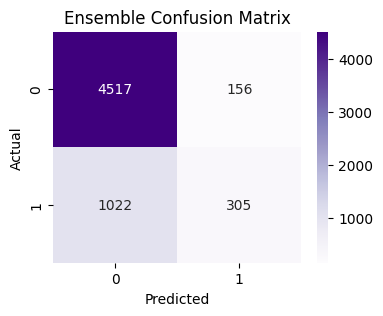

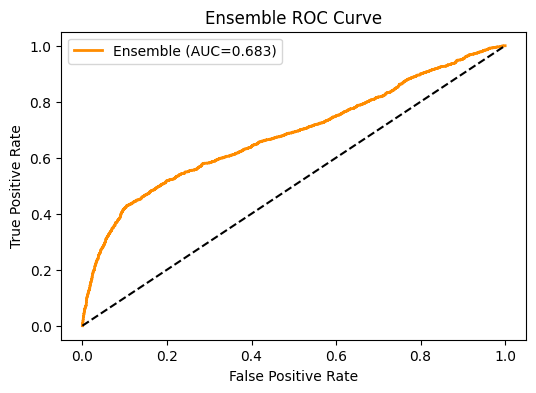

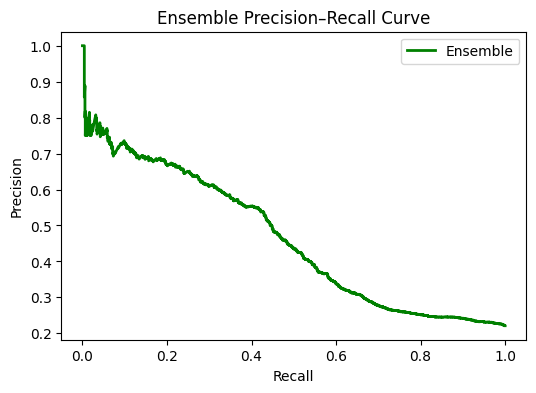

In [13]:
# ================================================================
# ✅ ENSEMBLE MODEL: Logistic + Random Forest + XGBoost
# ================================================================
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, precision_recall_curve, mean_squared_error,
    mean_absolute_error
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -------------------- Define Base Models --------------------
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

base_learners = [
    ("logistic", LogisticRegression(max_iter=500, solver="lbfgs")),
    ("rf", RandomForestClassifier(n_estimators=100, random_state=42)),
    ("xgb", XGBClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=5,
        subsample=0.8, colsample_bytree=0.8, use_label_encoder=False,
        eval_metric="logloss", random_state=42
    ))
]

# Meta-model (uses base model predictions as input)
meta_model = LogisticRegression(max_iter=500)

# -------------------- Build Ensemble --------------------
ensemble = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_model,
    stack_method="predict_proba",  # use probabilities from base learners
    passthrough=True,
    n_jobs=-1
)

# -------------------- Train Ensemble --------------------
print("🚀 Training Ensemble (Logistic + RF + XGBoost)...")
ensemble.fit(X_train, y_train)
y_pred = ensemble.predict(X_test)
y_proba = ensemble.predict_proba(X_test)[:, 1]

# -------------------- Evaluate --------------------
roc_auc = roc_auc_score(y_test, y_proba)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
err = 1 - acc
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
cm = confusion_matrix(y_test, y_pred)

print("\n📊 Ensemble Model Metrics:")
print(f" Accuracy={acc:.4f} | Precision={prec:.4f} | Recall={rec:.4f} | "
      f"F1={f1:.4f} | ROC-AUC={roc_auc:.4f}")
print(f" Error={err:.4f} | MSE={mse:.4f} | MAE={mae:.4f} | RMSE={rmse:.4f}")

# -------------------- Confusion Matrix --------------------
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title("Ensemble Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

# -------------------- ROC Curve --------------------
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"Ensemble (AUC={roc_auc:.3f})")
plt.plot([0,1], [0,1], 'k--')
plt.title("Ensemble ROC Curve")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.legend(); plt.show()

# -------------------- Precision–Recall Curve --------------------
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba)
plt.figure(figsize=(6,4))
plt.plot(rec_curve, prec_curve, color='green', lw=2, label="Ensemble")
plt.title("Ensemble Precision–Recall Curve")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.legend(); plt.show()


In [14]:
# -------------------- Safe Ensemble Load or Train --------------------
import joblib, os, io, pandas as pd, numpy as np
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

# If you already uploaded your file
df = pd.read_csv(io.BytesIO(uploaded[file_name]))
if "ID" in df.columns:
    df = df.drop(columns=["ID"])

X = df.drop(columns=["default.payment.next.month"]).values
y = df["default.payment.next.month"].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

os.makedirs("models", exist_ok=True)
model_path = "models/Ensemble_final.pkl"

# --- Build ensemble ---
if not os.path.exists(model_path):
    print("⚙️ Training new ensemble model (since it wasn't found)...")
    model1 = LogisticRegression(max_iter=500, solver="lbfgs")
    model2 = RandomForestClassifier(n_estimators=100, random_state=42)
    model3 = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

    ensemble_model = VotingClassifier(
        estimators=[('lr', model1), ('rf', model2), ('xgb', model3)],
        voting='soft'
    )
    ensemble_model.fit(X_train, y_train)
    joblib.dump(ensemble_model, model_path)
    print(f"✅ Ensemble model trained & saved to {model_path}")
else:
    print("✅ Loading existing ensemble model...")
    ensemble_model = joblib.load(model_path)

# --- Predict fraud and non-fraud ---
y_pred = ensemble_model.predict(X)
df["Predicted_Label"] = y_pred
fraud_cases = df[df["Predicted_Label"] == 1]
non_fraud_cases = df[df["Predicted_Label"] == 0]

print(f"\nTotal: {len(df)} | Fraud: {len(fraud_cases)} | Non-Fraud: {len(non_fraud_cases)}")
print("\n🔴 Fraudulent transactions:")
print(fraud_cases.head())

print("\n🟢 Legitimate transactions:")
print(non_fraud_cases.head())


⚙️ Training new ensemble model (since it wasn't found)...
✅ Ensemble model trained & saved to models/Ensemble_final.pkl

Total: 30000 | Fraud: 3695 | Non-Fraud: 26305

🔴 Fraudulent transactions:
    LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0     20000.0    2          2         1   24      2      2     -1     -1   
13    70000.0    1          2         2   30      1      2      2      0   
16    20000.0    1          1         2   24      0      0      2      2   
22    70000.0    2          2         2   26      2      0      0      2   
31    50000.0    1          2         2   33      2      0      0      0   

    PAY_5  ...  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  \
0      -2  ...        0.0        0.0       0.0     689.0       0.0       0.0   
13      0  ...    36137.0    36894.0    3200.0       0.0    3000.0    3000.0   
16      2  ...    17905.0    19104.0    3200.0       0.0    1500.0       0.0   
22      2  ...    46905.0   

In [15]:
# -------------------- Single Input Fraud Prediction --------------------
import numpy as np
import pandas as pd
import joblib
import io

# Load your trained ensemble model
model_path = "models/Ensemble_final.pkl"
ensemble_model = joblib.load(model_path)

# Load dataset to know feature structure
df = pd.read_csv(io.BytesIO(uploaded[file_name]))
if "ID" in df.columns:
    df = df.drop(columns=["ID"])

target_col = "default.payment.next.month"
feature_names = [c for c in df.columns if c != target_col]

# Show user which features to input
print("🧩 Enter feature values in the same order as shown below:")
print(feature_names)

# Example: Let user manually enter values
# (You can replace input() with a predefined list for automation)
user_values = []
for col in feature_names:
    val = float(input(f"Enter value for '{col}': "))
    user_values.append(val)

# Convert to 2D array for prediction
X_user = np.array(user_values).reshape(1, -1)

# Predict fraud (1) or legitimate (0)
y_pred = ensemble_model.predict(X_user)[0]
y_proba = ensemble_model.predict_proba(X_user)[0][1]  # Probability of fraud

print("\n🔍 Prediction Result:")
if y_pred == 1:
    print(f"⚠️ This transaction is predicted as FRAUDULENT (probability = {y_proba:.2f})")
else:
    print(f"✅ This transaction is predicted as LEGITIMATE (probability of fraud = {y_proba:.2f})")


🧩 Enter feature values in the same order as shown below:
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
Enter value for 'LIMIT_BAL': 34
Enter value for 'SEX': 2
Enter value for 'EDUCATION': 2
Enter value for 'MARRIAGE': 2
Enter value for 'AGE': 26
Enter value for 'PAY_0': -1
Enter value for 'PAY_2': 2
Enter value for 'PAY_3': 0
Enter value for 'PAY_4': 0
Enter value for 'PAY_5': 0
Enter value for 'PAY_6': 0
Enter value for 'BILL_AMT1': 34
Enter value for 'BILL_AMT2': 0
Enter value for 'BILL_AMT3': 0
Enter value for 'BILL_AMT4': 0
Enter value for 'BILL_AMT5': 0
Enter value for 'BILL_AMT6': 0
Enter value for 'PAY_AMT1': 0
Enter value for 'PAY_AMT2': 0
Enter value for 'PAY_AMT3': 0
Enter value for 'PAY_AMT4': 0
Enter value for 'PAY_AMT5': 0
Enter value for 'PAY_AMT6': 0

🔍 Predictio

Enter a row index to check (0–29999): 13

🔍 Model Prediction: ⚠️ FRAUD
Probability of fraud: 0.6667
TreeExplainer failed — using KernelExplainer instead.


  0%|          | 0/1 [00:00<?, ?it/s]


Top features driving the prediction:


,Feature,Feature_Value,SHAP_Value
6,PAY_2,2.0,0.115275
7,PAY_3,2.0,0.054999
10,PAY_6,2.0,0.048247
5,PAY_0,1.0,0.048162
0,LIMIT_BAL,70000.0,0.043137
12,BILL_AMT2,67369.0,0.041850
14,BILL_AMT4,66782.0,0.037716
18,PAY_AMT2,0.0,0.025541
16,BILL_AMT6,36894.0,0.018398
17,PAY_AMT1,3200.0,0.016953


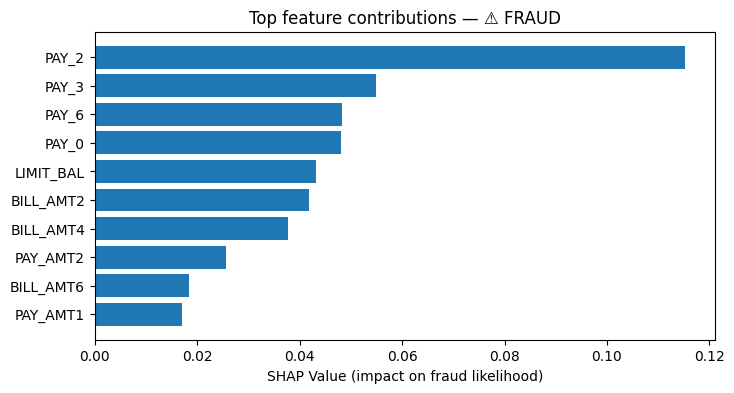

In [16]:
# -------------------- FRAUD / LEGITIMATE PREDICTION + EXPLANATION --------------------
!pip install shap --quiet

import shap, joblib, io, pandas as pd, numpy as np, matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.utils import check_array

# ========== Load trained ensemble ==========
ensemble_model = joblib.load("models/Ensemble_final.pkl")

# ========== Load dataset ==========
df = pd.read_csv(io.BytesIO(uploaded[file_name]))
if "ID" in df.columns:
    df = df.drop(columns=["ID"])

target_col = "default.payment.next.month"
X_df = df.drop(columns=[target_col])
y_df = df[target_col]
feature_names = X_df.columns

# ========== Choose a row to test ==========
row_index = int(input(f"Enter a row index to check (0–{len(X_df)-1}): "))
X_sample_df = X_df.iloc[[row_index]]
X_sample_arr = X_sample_df.values

# ========== Make prediction ==========
pred_proba = ensemble_model.predict_proba(X_sample_arr)[0][1]
pred_label = int(pred_proba >= 0.5)
result = "⚠️ FRAUD" if pred_label == 1 else "✅ LEGITIMATE"

print(f"\n🔍 Model Prediction: {result}")
print(f"Probability of fraud: {pred_proba:.4f}")

# ========== Find tree-based model for SHAP explanation ==========
xgb_model, rf_model = None, None
named = getattr(ensemble_model, "named_estimators_", None)
estimators = named if named is not None else dict(getattr(ensemble_model, "estimators_", []))
for name, est in estimators.items():
    if isinstance(est, XGBClassifier):
        xgb_model = est
        break
    if isinstance(est, RandomForestClassifier):
        rf_model = est

submodel = xgb_model if xgb_model is not None else (rf_model if rf_model is not None else None)
if submodel is None:
    raise RuntimeError("No XGBClassifier or RandomForestClassifier found for SHAP explanation.")

# ========== Try SHAP explanation ==========
X_background = X_df.sample(min(100, len(X_df)), random_state=42)
X_background_arr = X_background.values

explainer = None
shap_values = None
try:
    if isinstance(submodel, XGBClassifier) and hasattr(submodel, "get_booster"):
        booster = submodel.get_booster()
        explainer = shap.TreeExplainer(booster)
    else:
        explainer = shap.TreeExplainer(submodel)
    shap_expl = explainer(X_sample_df)
    shap_values = shap_expl.values if hasattr(shap_expl, "values") else shap_expl
    base_value = shap_expl.base_values if hasattr(shap_expl, "base_values") else None
    used_explainer = "TreeExplainer"
except Exception as e_tree:
    print("TreeExplainer failed — using KernelExplainer instead.")
    def predict_pos(x): return ensemble_model.predict_proba(x)[:, 1]
    explainer = shap.KernelExplainer(predict_pos, X_background_arr[:50, :])
    shap_values = explainer.shap_values(X_sample_arr, nsamples=200)
    base_value = None
    used_explainer = "KernelExplainer"

# ========== Summarize feature contributions ==========
if isinstance(shap_values, list):
    shap_arr = np.asarray(shap_values[1] if len(shap_values) > 1 else shap_values[0])
else:
    shap_arr = np.asarray(shap_values)
shap_row = shap_arr[0] if shap_arr.ndim == 2 else shap_arr

shap_df = pd.DataFrame({
    "Feature": feature_names,
    "Feature_Value": X_sample_df.iloc[0].values,
    "SHAP_Value": shap_row
}).sort_values("SHAP_Value", key=abs, ascending=False)

print("\nTop features driving the prediction:")
display(shap_df.head(10))

# ========== Visualization ==========
try:
    shap.initjs()
    shap.plots.waterfall(shap.Explanation(values=shap_row, base_values=base_value, data=X_sample_df.iloc[0], feature_names=feature_names))
except Exception:
    plt.figure(figsize=(8, 4))
    top = shap_df.head(10).sort_values("SHAP_Value")
    plt.barh(top["Feature"], top["SHAP_Value"])
    plt.xlabel("SHAP Value (impact on fraud likelihood)")
    plt.title(f"Top feature contributions — {result}")
    plt.show()



🔍 Running Isolation Forest for anomaly detection...

📊 Isolation Forest vs Actual Fraud:
ActualFraud          0     1
AnomalyDetected             
0                22692  6408
1                  672   228


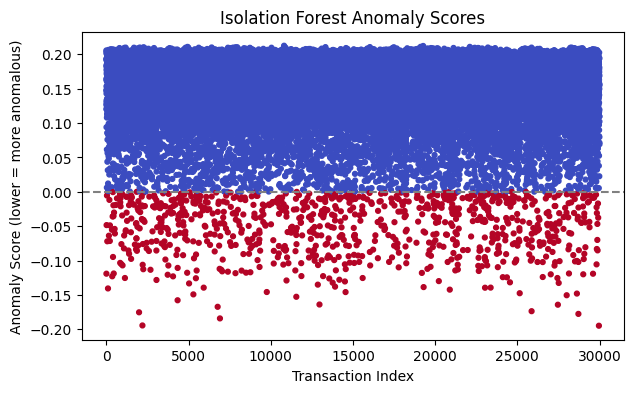


⚠️ Total anomalies detected: 900
     LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
6     500000.0    1          1         2   29      0      0      0      0   
17    320000.0    1          1         1   49      0      0      0     -1   
40    360000.0    1          1         2   33      0      0      0      0   
59    400000.0    2          2         1   29      0      0      0      0   
102   480000.0    1          1         1   63      0      0      0      2   

     PAY_5  ...  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  \
6        0  ...   483003.0   473944.0   55000.0   40000.0   38000.0   20239.0   
17      -1  ...     5856.0   195599.0   10358.0   10000.0   75940.0   20000.0   
40       0  ...   195969.0   179224.0   10000.0    7000.0    6000.0  188840.0   
59       0  ...   356656.0   364089.0   17000.0   15029.0   30000.0   12000.0   
102      2  ...   471145.0   469961.0   16078.0   55693.0   17000.0       0.0   

     PAY_AMT5  P

  0%|          | 0/1 [00:00<?, ?it/s]


Top features driving the prediction:


,Feature,Feature_Value,SHAP_Value
0,LIMIT_BAL,50000.0,0.029111
5,PAY_0,0.0,-0.027184
20,PAY_AMT4,109.0,-0.008837
6,PAY_2,0.0,-0.008498
12,BILL_AMT2,9199.0,-0.008152
11,BILL_AMT1,13538.0,-0.007441
16,BILL_AMT6,5440.0,-0.006866
17,PAY_AMT1,2000.0,-0.006811
14,BILL_AMT4,6753.0,0.001514
9,PAY_5,0.0,-0.001418


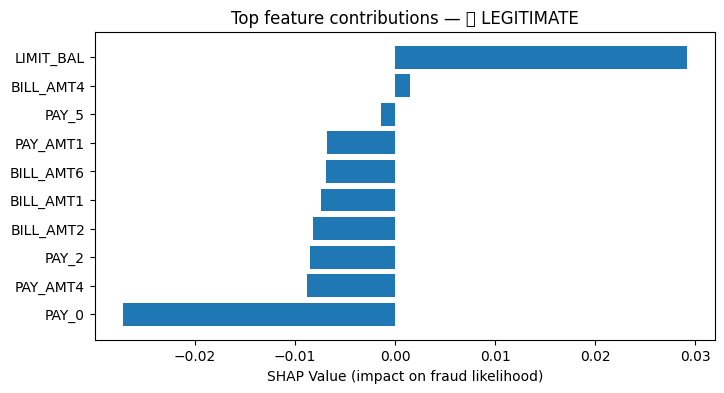

In [17]:
# -------------------- FRAUD / LEGITIMATE PREDICTION + ANOMALY DETECTION + EXPLANATION --------------------
!pip install shap --quiet

import shap, joblib, io, pandas as pd, numpy as np, matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier, IsolationForest
from sklearn.utils import check_array

# ========== Load trained ensemble ==========
ensemble_model = joblib.load("models/Ensemble_final.pkl")

# ========== Load dataset ==========
df = pd.read_csv(io.BytesIO(uploaded[file_name]))
if "ID" in df.columns:
    df = df.drop(columns=["ID"])

target_col = "default.payment.next.month"
X_df = df.drop(columns=[target_col])
y_df = df[target_col]
feature_names = X_df.columns

# ================================================================
# 🔍 UNSUPERVISED ANOMALY DETECTION USING ISOLATION FOREST
# ================================================================
print("\n🔍 Running Isolation Forest for anomaly detection...")

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.03,   # assume 3% anomalies
    random_state=42
)
iso_labels = iso_forest.fit_predict(X_df)

# Convert to readable labels
df["Anomaly_Label"] = np.where(iso_labels == -1, 1, 0)  # 1 = anomaly, 0 = normal

# Compare anomaly detection with actual fraud labels
anomaly_summary = pd.crosstab(df["Anomaly_Label"], df[target_col],
                              rownames=["AnomalyDetected"], colnames=["ActualFraud"])
print("\n📊 Isolation Forest vs Actual Fraud:")
print(anomaly_summary)

# Visualize anomaly scores
plt.figure(figsize=(7, 4))
plt.scatter(range(len(X_df)), iso_forest.decision_function(X_df),
            c=df["Anomaly_Label"], cmap="coolwarm", s=12)
plt.axhline(0, color="gray", linestyle="--")
plt.title("Isolation Forest Anomaly Scores")
plt.xlabel("Transaction Index")
plt.ylabel("Anomaly Score (lower = more anomalous)")
plt.show()

# Save subset of anomalies for inspection
anomalies = df[df["Anomaly_Label"] == 1]
print(f"\n⚠️ Total anomalies detected: {len(anomalies)}")
print(anomalies.head())

# ================================================================
# ✅ SUPERVISED FRAUD PREDICTION USING ENSEMBLE MODEL
# ================================================================
row_index = int(input(f"\nEnter a row index to check (0–{len(X_df)-1}): "))
X_sample_df = X_df.iloc[[row_index]]
X_sample_arr = X_sample_df.values

pred_proba = ensemble_model.predict_proba(X_sample_arr)[0][1]
pred_label = int(pred_proba >= 0.5)
result = "⚠️ FRAUD" if pred_label == 1 else "✅ LEGITIMATE"

print(f"\n🔍 Model Prediction: {result}")
print(f"Probability of fraud: {pred_proba:.4f}")

# ================================================================
# 📊 SHAP FEATURE EXPLANATION
# ================================================================
xgb_model, rf_model = None, None
named = getattr(ensemble_model, "named_estimators_", None)
estimators = named if named is not None else dict(getattr(ensemble_model, "estimators_", []))
for name, est in estimators.items():
    if isinstance(est, XGBClassifier):
        xgb_model = est
        break
    if isinstance(est, RandomForestClassifier):
        rf_model = est

submodel = xgb_model if xgb_model is not None else (rf_model if rf_model is not None else None)
if submodel is None:
    raise RuntimeError("No XGBClassifier or RandomForestClassifier found for SHAP explanation.")

# ---- Try TreeExplainer first, fallback to KernelExplainer ----
X_background = X_df.sample(min(100, len(X_df)), random_state=42)
X_background_arr = X_background.values

explainer = None
shap_values = None
try:
    if isinstance(submodel, XGBClassifier) and hasattr(submodel, "get_booster"):
        booster = submodel.get_booster()
        explainer = shap.TreeExplainer(booster)
    else:
        explainer = shap.TreeExplainer(submodel)
    shap_expl = explainer(X_sample_df)
    shap_values = shap_expl.values if hasattr(shap_expl, "values") else shap_expl
    base_value = shap_expl.base_values if hasattr(shap_expl, "base_values") else None
except Exception as e_tree:
    print("TreeExplainer failed — using KernelExplainer instead.")
    def predict_pos(x): return ensemble_model.predict_proba(x)[:, 1]
    explainer = shap.KernelExplainer(predict_pos, X_background_arr[:50, :])
    shap_values = explainer.shap_values(X_sample_arr, nsamples=200)
    base_value = None

# ---- Summarize SHAP feature impact ----
if isinstance(shap_values, list):
    shap_arr = np.asarray(shap_values[1] if len(shap_values) > 1 else shap_values[0])
else:
    shap_arr = np.asarray(shap_values)
shap_row = shap_arr[0] if shap_arr.ndim == 2 else shap_arr

shap_df = pd.DataFrame({
    "Feature": feature_names,
    "Feature_Value": X_sample_df.iloc[0].values,
    "SHAP_Value": shap_row
}).sort_values("SHAP_Value", key=abs, ascending=False)

print("\nTop features driving the prediction:")
display(shap_df.head(10))

# ---- Visualize SHAP waterfall ----
try:
    shap.initjs()
    shap.plots.waterfall(
        shap.Explanation(values=shap_row, base_values=base_value,
                         data=X_sample_df.iloc[0], feature_names=feature_names)
    )
except Exception:
    plt.figure(figsize=(8, 4))
    top = shap_df.head(10).sort_values("SHAP_Value")
    plt.barh(top["Feature"], top["SHAP_Value"])
    plt.xlabel("SHAP Value (impact on fraud likelihood)")
    plt.title(f"Top feature contributions — {result}")
    plt.show()
